Image loaded with shape: (1024, 1536, 3)
Running random_walker segmentation...
Segmentation done.


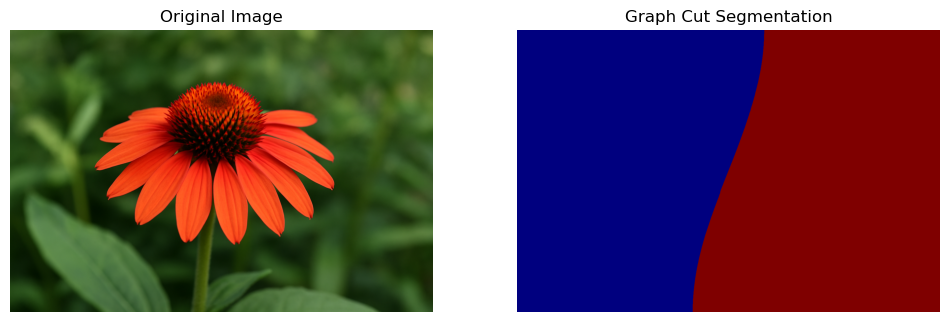

In [1]:
import cv2
import numpy as np
from skimage.segmentation import random_walker
import matplotlib.pyplot as plt

def graph_cut_segmentation(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise Exception("Image not found.")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    print(f"Image loaded with shape: {img.shape}")

    # Seeds for random walker
    markers = np.zeros((h, w), dtype=np.uint8)
    markers[10:80, 10:80] = 1        # Foreground seed
    markers[h-80:h-10, w-80:w-10] = 2  # Background seed

    print("Running random_walker segmentation...")
    labels = random_walker(img, markers, beta=10, mode='bf', channel_axis=-1)
    print("Segmentation done.")

    # Plot results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(labels, cmap="jet")
    plt.title("Graph Cut Segmentation")
    plt.axis("off")

    plt.savefig("output_random_walker.png")
    plt.show()


if __name__ == "__main__":
    image_path = "img.png"  # Change to your image path
    graph_cut_segmentation(image_path)
